In [238]:
import pandas as pd 
import numpy as np
import seaborn as sns # visualizations
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier # cassification problem
from sklearn.model_selection import train_test_split # we split the data to use it well 
from sklearn.metrics import r2_score, accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay # evaluation metric  - R^2 
import matplotlib.pyplot as plt # aids in visualization

#### **Load Data**

In [239]:
data = load_wine() 

In [240]:
data

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [241]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [242]:
X.head(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0


In [243]:
print(np.unique(y, return_counts=True))

(array([0, 1, 2]), array([59, 71, 48]))


In [244]:
X.shape

(178, 13)

In [245]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.25, random_state=42, stratify=y
)

# 
print(X_train.shape) 
print(X_test.shape) 

(133, 13)
(45, 13)


## **Modeling**

Expression of variance in DTs

In [246]:
def decisionTree(random_state):
    dt_model = DecisionTreeClassifier(random_state = random_state)
    dt_model.fit(X_train, y_train)
    y_dt_predict = dt_model.predict(X_test)
    print(f"accuracy_score: {accuracy_score(y_test, y_dt_predict)}")

In [247]:
decisionTree(50) 

accuracy_score: 0.9777777777777777


In [248]:
decisionTree(2) 

accuracy_score: 0.9777777777777777


In [249]:
decisionTree(42) 

accuracy_score: 0.9555555555555556


In [250]:
decisionTree(65) 

accuracy_score: 0.9111111111111111


In [251]:
decisionTree(99) 

accuracy_score: 0.9777777777777777


Random Forest

In [252]:
rf_model = RandomForestClassifier(
    n_estimators=100, # number of trees
    min_samples_leaf= 13,
    max_features='sqrt', # features considered per split(random in nature)
    max_depth =None, # let the three grow fully 
    bootstrap=True, # settles on bagging approach hence psample is picked with replacement
    oob_score=True,   
    random_state= 42, 
    n_jobs=-1, 
)

In [253]:
rf_model.fit(X_train, y_train) # model training
rf_y_pred = rf_model.predict(X_test) # prediction

## **Evaluation**

In [254]:
print(f" ACCCURACY: {accuracy_score(y_test, rf_y_pred)}")

 ACCCURACY: 0.9555555555555556


In [255]:
print(f" OOB Score: {rf_model.oob_score_}")

 OOB Score: 0.9774436090225563


In [256]:
print(classification_report(y_test, rf_y_pred, target_names= data.target_names))

              precision    recall  f1-score   support

     class_0       0.94      1.00      0.97        15
     class_1       1.00      0.89      0.94        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [257]:
cm = confusion_matrix(y_test, rf_y_pred)
cm

array([[15,  0,  0],
       [ 1, 16,  1],
       [ 0,  0, 12]])

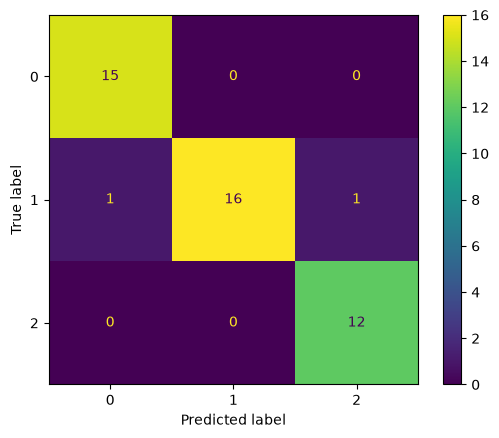

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot() 
plt.show()